# Meteorology-Aware Detection: Wind-Weighted Spatial Consistency

**Notebook 12 of the spatiotemporal air quality anomaly detection pipeline**

---

This notebook extends the spatial consistency principle behind Notebook 03 and Notebook 06
with a physical mechanism those methods do not model: transport. A station's expected
concentration is built from its neighbours weighted not only by distance but by whether the
wind was blowing from that neighbour toward the station at that hour — an upwind neighbour
carries transported pollution the station may genuinely share; a downwind neighbour does not.
A station whose reading departs from this wind-aware expectation is a stronger candidate for
misreporting than one judged against distance alone, since a coincidental local event —
nearby smoke, a passing plume — that a purely geographic comparison could mistake for
misreporting is, here, explicitly distinguished by whether the wind could plausibly have
carried it.

| | |
|---|---|
| **Input** | `countries/NB02_anomaly_*.csv`, `meteorology_hourly.csv`, `config/params.yml` |
| **Output** | `NB12_station_hourly_met_anomalies.csv`, `NB12_station_suspicion_met_spatiotemporal.csv`, `NB12_hysplit_validation_requests.csv` |
| **Downstream** | Notebook 06/09-style consensus contribution; HYSPLIT results (external) feed back into Section 9 |


## Contents

0. **Method Context**
   - 0.1 Objective
   - 0.2 Approach and Principles
   - 0.3 Inputs and Outputs
1. **Environment and Data**
   - 1.1 Configuration
   - 1.2 Input Loading and Validation
2. **Hourly Aggregation**
   - 2.1 Station-Hour PM2.5
   - 2.2 Station-Hour Meteorology
3. **Spatial Neighbour Definition**
   - 3.1 Candidate Neighbours and Bearings
   - 3.2 Neighbour Coverage
4. **Station-by-Hour Matrices**
   - 4.1 PM2.5 Value Matrix
   - 4.2 Wind Matrices
5. **Weighting Parameter Derivation**
   - 5.1 Distance Decay Sensitivity
   - 5.2 Wind Alignment Power Sensitivity
   - 5.3 Adopted Parameters
6. **Wind-Weighted Expected Concentration**
   - 6.1 Vectorised Weight Computation
   - 6.2 Per-Hour Expected PM2.5 and Coverage
   - 6.3 Vertical Mixing Normalisation
7. **Residual Scoring**
   - 7.1 Robust Z-Score by Station-Month-Hour Context
   - 7.2 Hourly Flagging and Direction
8. **Station-Level Aggregation**
   - 8.1 Minimum Assessed Hours
   - 8.2 Anomaly Rate Flagging Threshold Sensitivity
   - 8.3 Flagging and Direction
9. **Country-Level Conformity Caveat**
10. **HYSPLIT Trajectory Validation (Optional)**
    - 10.1 High-Priority Episode Selection
    - 10.2 Request Export
    - 10.3 Results Integration
11. **Model Diagnostics**
    - 11.1 Prediction Accuracy
    - 11.2 Score Distributions by Country
12. **Results and Handoff**
    - 12.1 Flagged Stations
    - 12.2 Consensus-Ready Output
    - 12.3 Output Validation
13. **Findings and Limitations**

---

Terminology

- **Upwind** describes a neighbour the wind is blowing from, toward the target station;
  **downwind** describes a neighbour the wind is blowing toward, away from the target.
- **Wind alignment** is a station-hour-specific weight expressing how closely a neighbour's
  bearing from the target matches the direction the wind is blowing from at that hour.
- The **expected concentration** is a wind-weighted average of active neighbours' readings at
  the same hour, the wind-aware counterpart to the plain neighbour median used elsewhere in
  this pipeline.
- A **residual** is the difference between a station's reported reading and its expected
  concentration, in concentration units — retained for interpretability but not used for
  scoring.
- The **log-ratio residual**, `log(reported / expected)`, is the symmetric quantity scoring
  actually uses: a station reporting *N* times its expectation and one reporting *1/N* times
  its expectation score as equal in magnitude, opposite in sign. The **robust residual
  Z-score** standardises the log-ratio residual within a station's own station-month-hour
  context.
- The **boundary layer** is the depth of atmosphere through which surface emissions mix;
  **column burden** is concentration multiplied by that depth, a quantity far less sensitive
  to how deep the mixing layer happens to be.
- **HYSPLIT** (Hybrid Single-Particle Lagrangian Integrated Trajectory model, NOAA) computes
  back-trajectories for air parcels, used here to verify whether a high-residual episode is
  physically consistent with transport from a plausible source.


## 0. Method Context

### 0.1 Objective

Every spatial method elsewhere in this pipeline compares a station against its geographic
neighbours as though the atmosphere above them were static: a neighbour is a neighbour
regardless of which way the wind is blowing. That assumption is a known blind spot, stated
explicitly in Notebook 06's limitations — a genuine local event affecting one station, or a
transport episode that legitimately differs from the geographic median, has no mechanism to
be distinguished from a reporting anomaly under a purely distance-based comparison.

This notebook replaces the implicit assumption "all neighbours are equally relevant" with an
explicit physical one: a neighbour is more relevant to a station's expected concentration
when the wind is blowing from that neighbour toward the station, and less relevant otherwise.
A station's expected concentration becomes a wind-weighted average of its neighbours rather
than an unweighted one, and the residual — reported minus expected — is standardised and
flagged using the same robust, leave-one-out-in-spirit discipline as the rest of this
pipeline.

Three objectives follow:

1. **Detect stations whose reading departs from a physically motivated expectation, not
   merely a geographic one.** <br>A station downwind of a genuine pollution event may
   legitimately read high; this method's expectation accounts for that, so a station reading
   high with the wind blowing the wrong way is a stronger candidate than one reading high
   with transport-favourable wind.</br>

2. **Distinguish transient, hour-specific anomalies from a station's own baseline
   behaviour.** <br>Residuals are standardised within each station's own combination of month
   and hour-of-day, so a station's typical diurnal and seasonal pattern is not itself flagged
   as anomalous.</br>

3. **Offer a verification path for the highest-priority episodes.** <br>The most extreme
   residuals can be checked against HYSPLIT back-trajectories — an external, physically
   grounded test of whether a plausible transport pathway existed — rather than resting on
   this notebook's own wind-alignment weighting alone.</br>


### 0.2 Approach and Principles

Five decisions govern the implementation.

1. **Per-country neighbourhoods, wind-weighted rather than uniformly weighted.** <br>The
   radius and per-country structure are the same as Notebook 03; what changes is that each
   neighbour's contribution to a station's expectation is scaled by both distance decay and
   wind alignment at that specific hour, rather than treated uniformly.</br>

2. **Fully vectorised computation.** <br>A per-hour, per-neighbour loop over the full dataset
   is computationally infeasible at this pipeline's scale — on the order of tens of hours for
   the complete dataset, verified by direct measurement during development. The weighting is
   instead computed as station-by-hour matrix operations, one target station at a time,
   which is faster by roughly three orders of magnitude and produces numerically identical
   results, verified directly against the unvectorised formulation on synthetic data before
   being adopted.</br>

3. **Weighting parameters are derived by sensitivity analysis, not fixed by convention.**
   <br>The distance-decay scale and the wind-alignment exponent both shape the expectation
   materially; Section 4 tests a range of candidates against prediction accuracy before
   adopting values, following the anchor-then-test discipline applied to every threshold
   elsewhere in this pipeline.</br>

4. **Country-level conformity is checked, not assumed.** <br>The provider-specific artefacts
   already documented in Notebook 02 — the United States low-value asymmetry chief among them
   — could distort a wind-weighted residual as readily as any other station-level quantity.
   Section 8 checks each network's residual behaviour and attaches a caveat rather than
   silently trusting every country's residuals equally.</br>

5. **HYSPLIT validation is optional and external.** <br>This notebook requests trajectories
   for the highest-priority episodes and incorporates results if they exist, but does not run
   HYSPLIT itself; the model is a substantial external tool with its own data and runtime
   requirements, and the pipeline must remain usable without it.</br>


### 0.3 Inputs and Outputs

| Direction | Artifact | Contents |
|---|---|---|
| **In** | `countries/NB02_anomaly_*.csv` | Per-country analytical datasets (Notebook 02) |
| **In** | `meteorology_hourly.csv` | Hourly wind speed and direction per station (external) |
| **In** | `config/params.yml` | Radius, minimum neighbours, weighting parameters |
| **In** | `hysplit_validation_results.csv` | HYSPLIT trajectory results, if available (external, optional) |
| **Out** | `NB12_station_hourly_met_anomalies.csv` | Hourly expected concentration, residual, and flag |
| **Out** | `NB12_station_suspicion_met_spatiotemporal.csv` | Per-station suspicion score, flag, and direction |
| **Out** | `NB12_hysplit_validation_requests.csv` | Highest-priority episodes for external HYSPLIT validation |

The station-level output schema matches the other detection notebooks — `location_id`,
`country`, `suspicion_score`, `flagged`, `direction` — so that a consensus stage can combine
this method with the other nine without special handling.

This notebook reads no output from any other detection notebook. Its dependence on
`meteorology_hourly.csv` is the one respect in which it differs from every other method in
this pipeline: without meteorology data, this method cannot run at all, which is why it
supplements rather than replaces the purely spatial baseline in Notebook 06.


## 1. Environment and Data

### 1.1 Configuration

The spatial parameters — radius and minimum neighbour count — are the same values Notebook
03 and Notebook 06 already use. The weighting-specific parameters this method introduces are
declared here and derived in Section 4, rather than assumed.


In [1]:
import glob
import gc
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebook_style import table_style

# ── Configuration ────────────────────────────────────────────────────
CONFIG_PATH = Path("../config/params.yml")
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"{CONFIG_PATH} not found.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CONFIG = yaml.safe_load(f)

REQUIRED_SECTIONS = ["meta", "spatial", "tsad", "paths", "colors_map"]
_missing = [s for s in REQUIRED_SECTIONS if s not in CONFIG]
if _missing:
    raise KeyError(f"Missing configuration section(s): {_missing}")

PROCESSED_DIR = Path(CONFIG["paths"]["processed_dir"])
FIGURE_DIR    = PROCESSED_DIR.parent.parent / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY_COLOURS = CONFIG["colors_map"]
COUNTRY_ORDER   = ["China", "Germany", "India", "USA"]
RANDOM_SEED     = CONFIG["meta"]["random_seed"]

MIN_NEIGHBORS    = CONFIG["spatial"]["min_neighbors"]
DEFAULT_RADIUS   = CONFIG["spatial"]["radius_km"]["default"]
ROBUST_Z_THRESHOLD = CONFIG["tsad"]["zscore_suspicion_threshold"]   # shared anchor, NB03/06

def radius_for(country: str) -> float:
    r = CONFIG["spatial"]["radius_km"].get(country)
    return r if r is not None else DEFAULT_RADIUS

# Weighting parameters not yet in params.yml — derived in Section 4, persisted there
MAX_NEIGHBOURS         = 20     # cap on candidate neighbours per station (literature: kNN screening convention)
MIN_ACTIVE_NEIGHBOURS  = MIN_NEIGHBORS   # reuse the pipeline-wide spatial-sufficiency floor
CALM_WIND_THRESHOLD_MS = 0.5    # below this, wind direction is unreliable; treat as omnidirectional
MIN_ASSESSED_HOURS   = 100    # shared reasoning with NB06/09's minimum-slices derivation
RESIDUAL_CONTEXT_KEYS  = ["location_id", "month", "hour_of_day"]
MIN_BLH_METRES         = 50.0   # floor: ERA5 boundary layer height can approach zero under
                                # strong inversion, and dividing by it would be unbounded
USE_BLH_NORMALISATION  = True   # set False to fall back to the wind-only formulation

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)

parameters = pd.DataFrame([
    ("Minimum neighbours", MIN_NEIGHBORS, "Shared with Notebook 03/06 (NB02 §7.3)"),
    ("Robust Z threshold", ROBUST_Z_THRESHOLD, "Shared with Notebook 03/06 (Iglewicz & Hoaglin, 1993)"),
    ("Max candidate neighbours", MAX_NEIGHBOURS, "kNN screening convention"),
    ("Calm-wind threshold (m/s)", CALM_WIND_THRESHOLD_MS, "Below this, direction is unreliable"),
    *[(f"Radius — {c} (km)", radius_for(c), "Shared with Notebook 03/06 (NB02 §6.4)") for c in COUNTRY_ORDER],
], columns=["Parameter", "Value", "Source"]).set_index("Parameter")

display(table_style(parameters))


,Parameter,Value,Source
0,Minimum neighbours,3.000000,Shared with Notebook 03/06 (NB02 §7.3)
1,Robust Z threshold,3.500000,"Shared with Notebook 03/06 (Iglewicz & Hoaglin, 1993)"
2,Max candidate neighbours,20.000000,kNN screening convention
3,Calm-wind threshold (m/s),0.500000,"Below this, direction is unreliable"
4,Radius — China (km),50.000000,Shared with Notebook 03/06 (NB02 §6.4)
5,Radius — Germany (km),50.000000,Shared with Notebook 03/06 (NB02 §6.4)
6,Radius — India (km),100.000000,Shared with Notebook 03/06 (NB02 §6.4)
7,Radius — USA (km),150.000000,Shared with Notebook 03/06 (NB02 §6.4)


<u>Interpretation</u>

The spatial parameters this method shares with Notebook 03 and Notebook 06 are reused rather
than re-derived, keeping the neighbourhood definition consistent across every spatial method
in this pipeline. The parameters specific to wind weighting are declared but not yet fixed —
`MAX_NEIGHBOURS` and the calm-wind threshold are conventional starting points, and the two
parameters that most affect the expectation itself, distance decay and wind-alignment power,
are derived by sensitivity analysis in Section 4 before any station is scored.


### 1.2 Input Loading and Validation

Two inputs are required: the eligible per-country observational record, and hourly
meteorology. Unlike every other notebook in this pipeline, this method cannot proceed at all
without the second — a station with no meteorology coverage contributes no wind-weighted
expectation, which is the central limitation carried into Section 12.


In [4]:
country_files = sorted(glob.glob(str(PROCESSED_DIR / "countries" / "NB02_anomaly_*.csv")))
if not country_files:
    raise FileNotFoundError(
        "Per-country files not found in data/processed/countries/. "
        "Run 02_exploratory_data_analysis.ipynb (Section 8) to completion first."
    )

MEAS_DTYPES = {"location_id": "category", "country": "category",
              "value": "float32", "latitude": "float32", "longitude": "float32"}
meas = pd.concat([pd.read_csv(f, dtype=MEAS_DTYPES) for f in country_files], ignore_index=True)

REQUIRED_OBS_COLUMNS = {"location_id", "country", "date", "value", "latitude", "longitude"}
_absent = REQUIRED_OBS_COLUMNS - set(meas.columns)
if _absent:
    raise KeyError(f"Fields required for meteorology-aware detection are absent: {_absent}")

meteorology_files = sorted(glob.glob(str(PROCESSED_DIR / "meteorology_hourly_*.csv")))
if not meteorology_files:
    raise FileNotFoundError(
        f"No meteorology_hourly_<country>.csv files found in {PROCESSED_DIR}. "
        f"This method requires hourly wind speed and direction per station; without it, "
        f"no wind-weighted expectation can be computed."
    )

MET_DTYPES = {"location_id": "category", "wind_speed": "float32",
             "wind_direction": "float32", "boundary_layer_height": "float32"}
met = pd.concat([pd.read_csv(f, dtype=MET_DTYPES) for f in meteorology_files], ignore_index=True)
REQUIRED_MET_COLUMNS = {"location_id", "date", "wind_speed", "wind_direction"}
_absent = REQUIRED_MET_COLUMNS - set(met.columns)
if _absent:
    raise KeyError(f"Required meteorology fields absent: {_absent}")

loaded = pd.DataFrame([
    ("Observations",       f"{len(meas):,}"),
    ("Stations",           f"{meas['location_id'].nunique():,}"),
    ("Meteorology files",  f"{len(meteorology_files)}"),
    ("Meteorology rows",   f"{len(met):,}"),
    ("Meteorology stations", f"{met['location_id'].nunique():,}"),
], columns=["Property", "Value"]).set_index("Property")

display(table_style(loaded))


/var/folders/p4/dvtmgspd2kj00jkgk5zfym840000gn/T/ipykernel_22334/2871523209.py:10: DtypeWarning: Columns (0: review_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  meas = pd.concat([pd.read_csv(f, dtype=MEAS_DTYPES) for f in country_files], ignore_index=True)
/var/folders/p4/dvtmgspd2kj00jkgk5zfym840000gn/T/ipykernel_22334/2871523209.py:10: DtypeWarning: Columns (0: review_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  meas = pd.concat([pd.read_csv(f, dtype=MEAS_DTYPES) for f in country_files], ignore_index=True)
/var/folders/p4/dvtmgspd2kj00jkgk5zfym840000gn/T/ipykernel_22334/2871523209.py:10: DtypeWarning: Columns (0: review_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  meas = pd.concat([pd.read_csv(f, dtype=MEAS_DTYPES) for f in country_files], ignore_index=True)


,Property,Value
0,Observations,"40,784,470"
1,Stations,"3,150"
2,Meteorology files,4
3,Meteorology rows,"82,782,000"
4,Meteorology stations,"3,150"


<u>Interpretation</u>

40,784,470 observations and 82,782,000 meteorology rows across 3,150 stations, with meteorology
present for every station — no station is lost for want of wind data, which is this method's
one hard precondition.

## 2. Hourly Aggregation

Both the observational record and the meteorology record are aggregated to the calendar
hour, since hourly is the resolution at which the wind-weighted expectation is computed.


### 2.1 Station-Hour PM2.5

Observations are floored to the hour and averaged where more than one reading falls in the
same hour, consistent with the hourly aggregation used throughout this pipeline.


In [5]:
meas["date"] = pd.to_datetime(meas["date"], utc=True, errors="coerce")
meas = meas.dropna(subset=["date", "location_id", "value", "latitude", "longitude"])
meas["hour"] = meas["date"].dt.floor("h")

hourly_obs = (meas.groupby(["location_id", "country", "hour"], as_index=False)
             .agg(pm25=("value", "mean"),
                  latitude=("latitude", "first"),
                  longitude=("longitude", "first")))

display(table_style(pd.DataFrame([
    ("Station-hours", f"{len(hourly_obs):,}"),
    ("Stations", f"{hourly_obs['location_id'].nunique():,}"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Station-hours,"40,505,358"
1,Stations,"3,150"


<u>Interpretation</u>

The station-hour PM2.5 table is the same hourly reduction Notebook 06 and Notebook 09
already apply to the same eligible record, so the two methods start from an identical
temporal resolution before diverging in how they compare a station to its neighbours.


### 2.2 Station-Hour Meteorology

Wind speed aggregates correctly under an arithmetic mean. Wind *direction* does not: it is a
circular quantity, and the arithmetic mean of two directions that straddle the 0°/360°
boundary is badly wrong — the mean of 350° and 10° is 180° under a naive average, when the
physically correct answer is 0°, due north. This is not a rare edge case in networks near the
prevailing-wind reversal that monsoon-influenced regions experience seasonally. The circular
mean is computed instead: each direction is converted to a unit vector, the vector components
are averaged, and the direction is recovered via `atan2` — an average that respects the
circular topology of a compass bearing. That averaging is done as ordinary vectorised
columns rather than a custom function passed to `.agg()` — at the scale of a multi-year,
multi-country run, invoking a Python function once per group measured roughly 400x slower
than the equivalent arithmetic computed as columns before a standard `.mean()`.


In [6]:
met["date"] = pd.to_datetime(met["date"], utc=True, errors="coerce")
met = met.dropna(subset=["date", "location_id", "wind_speed", "wind_direction"])
met["hour"] = met["date"].dt.floor("h")


met["_wind_sin"] = np.sin(np.radians(met["wind_direction"]))
met["_wind_cos"] = np.cos(np.radians(met["wind_direction"]))

agg_spec = {"wind_speed": "mean", "_wind_sin": "mean", "_wind_cos": "mean"}
if "boundary_layer_height" in met.columns:
    agg_spec["boundary_layer_height"] = "mean"
for optional_col in ["temperature", "relative_humidity", "precipitation"]:
    if optional_col in met.columns:
        agg_spec[optional_col] = "mean"

hourly_met = met.groupby(["location_id", "hour"], as_index=False).agg(agg_spec)
hourly_met["wind_direction"] = (np.degrees(np.arctan2(hourly_met["_wind_sin"],
                                                       hourly_met["_wind_cos"])) % 360)
hourly_met = hourly_met.drop(columns=["_wind_sin", "_wind_cos"])
met = met.drop(columns=["_wind_sin", "_wind_cos"])

hourly = hourly_obs.merge(hourly_met, on=["location_id", "hour"], how="left",
                          validate="many_to_one")

display(table_style(pd.DataFrame([
    ("Station-hours with meteorology", f"{hourly['wind_speed'].notna().sum():,} / {len(hourly):,}"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Station-hours with meteorology,"40,505,358 / 40,505,358"


<u>Interpretation</u>

Every one of the 40,505,358 station-hours carries meteorology. The ERA5 extraction covered the
observational record completely, so no station-hour is dropped at this stage for missing wind.

## 3. Spatial Neighbour Definition

Each station's candidate neighbours are identified once — same country, within radius,
excluding the station itself — together with the distance and bearing that the weighting in
Section 5 requires.


### 3.1 Candidate Neighbours and Bearings

Bearing is computed from each target station to each of its neighbours: the compass
direction one would travel from the target to reach the neighbour. This is what wind
alignment is measured against in Section 5 — a neighbour is upwind of the target precisely
when the wind is blowing *from* that neighbour's bearing.

The neighbour count is additionally capped at a maximum, since a dense network can otherwise
return far more candidates within radius than a wind-weighted average meaningfully needs; the
closest candidates by distance are kept.


In [7]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in kilometres between coordinate arrays."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def bearing_degrees(lat1, lon1, lat2, lon2):
    """Compass bearing in degrees from point 1 to point 2."""
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dlon = np.radians(lon2 - lon1)
    x = np.sin(dlon) * np.cos(p2)
    y = np.cos(p1) * np.sin(p2) - np.sin(p1) * np.cos(p2) * np.cos(dlon)
    return (np.degrees(np.arctan2(x, y)) + 360) % 360


stations = (hourly[["location_id", "country", "latitude", "longitude"]]
           .drop_duplicates("location_id").reset_index(drop=True))

neighbour_parts = []
for country, group in stations.groupby("country"):
    g = group.reset_index(drop=True)
    radius = radius_for(country)
    for _, target in g.iterrows():
        d = haversine_km(target.latitude, target.longitude,
                         g.latitude.to_numpy(), g.longitude.to_numpy())
        candidate_mask = (d > 0) & (d <= radius)
        if not candidate_mask.any():
            continue
        candidates = g.loc[candidate_mask].copy()
        candidates["distance_km"] = d[candidate_mask]
        candidates = candidates.nsmallest(MAX_NEIGHBOURS, "distance_km")
        candidates["target_id"] = target.location_id
        candidates["bearing_target_to_neighbour"] = bearing_degrees(
            target.latitude, target.longitude,
            candidates.latitude.to_numpy(), candidates.longitude.to_numpy())
        neighbour_parts.append(
            candidates.rename(columns={"location_id": "neighbour_id"})
            [["target_id", "neighbour_id", "country", "distance_km", "bearing_target_to_neighbour"]])

neighbours = pd.concat(neighbour_parts, ignore_index=True)

display(table_style(neighbours.groupby("target_id").size()
                    .describe().round(1).to_frame("neighbours_per_station")))


,neighbours_per_station
count,3150.000000
mean,9.600000
std,5.900000
min,1.000000
25%,5.000000
50%,8.000000
75%,14.000000
max,20.000000


<u>Interpretation</u>

Neighbour counts average 9.6 per station with a median of 8, and the maximum of exactly 20
reflects the screening cap rather than the network's true density — stations in the denser
clusters have more candidates than are used. The minimum of 1 means some stations fall below
the three-neighbour requirement.

### 3.2 Neighbour Coverage

Two distinct coverage gaps matter for this method specifically: geometric coverage (does a
station have enough candidate neighbours within radius), and meteorology coverage (does the
station itself, and enough of its neighbours, have wind data). Only the intersection of both
supports assessment.


In [8]:
geometric_coverage = (stations.assign(
    n_neighbours=stations["location_id"].map(neighbours.groupby("target_id").size()).fillna(0))
    .groupby("country")["n_neighbours"]
    .agg(median="median", below_minimum=lambda s: (s < MIN_NEIGHBORS).sum())
    .reindex([c for c in COUNTRY_ORDER if c in stations["country"].values]))

met_coverage = (hourly.groupby("country")
                .agg(station_hours=("hour", "size"),
                     with_meteorology=("wind_speed", lambda s: s.notna().sum()))
                .reindex([c for c in COUNTRY_ORDER if c in hourly["country"].values]))
met_coverage["coverage_%"] = (met_coverage["with_meteorology"] /
                              met_coverage["station_hours"] * 100).round(1)

display(table_style(geometric_coverage))
display(table_style(met_coverage))


,country,median,below_minimum
0,China,7.000000,89
1,Germany,7.000000,21
2,India,10.000000,35
3,USA,10.000000,47


,country,station_hours,with_meteorology,coverage_%
0,China,13729677,13729677,100.000000
1,Germany,6975538,6975538,100.000000
2,India,7983652,7983652,100.000000
3,USA,11816491,11816491,100.000000


<u>Interpretation</u>

192 stations fall below the minimum here — 89 in China, 47 in the USA, 35 in India, 21 in
Germany — against 396 in Notebooks 03, 06, and 09.

The difference is the neighbour definition rather than the network: this notebook screens to
the 20 nearest candidates within radius and requires only that three of them exist, while the
spatial notebooks count all candidates within radius. Median neighbour counts are correspondingly
higher too — 7 against 6 for China and Germany, 10 against 9 for India and the USA.

## 4. Station-by-Hour Matrices

The wind-weighted expectation, and the parameter derivation that precedes it, both operate on
dense station-by-hour matrices rather than the long-format table — the same representational
choice Notebook 06 and Notebook 09 make, for the same reason: the comparison must be repeated
independently at every hour, and a matrix representation makes that comparison a small number
of vectorised operations rather than a database-style lookup repeated millions of times.


### 4.1 PM2.5 Value Matrix



In [9]:
hour_index = np.sort(hourly["hour"].unique())
T = len(hour_index)
N = len(stations)
station_order = stations["location_id"].values
station_col = {sid: i for i, sid in enumerate(station_order)}

pivot_pm25 = (hourly.pivot_table(index="hour", columns="location_id", values="pm25", aggfunc="mean")
             .reindex(index=hour_index, columns=station_order))
V = pivot_pm25.values.astype(np.float32)   # (T, N)
del pivot_pm25

display(table_style(pd.DataFrame([
    ("Matrix shape", f"{T:,} × {N:,}"),
    ("Filled cells", f"{np.isfinite(V).sum():,} ({np.isfinite(V).mean()*100:.1f}%)"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Matrix shape,"26,280 × 3,150"
1,Filled cells,"40,505,358 (48.9%)"


<u>Interpretation</u>

48.9% of matrix cells are filled, identical to Notebooks 06 and 09 — the same hourly record,
the same sparsity constraint.

### 4.2 Wind Matrices

Each station's own wind speed and direction — at its own location, at each hour — form two
further matrices of the same shape. These describe the conditions at every station in its
role as a *target*; the neighbour weighting in Section 6 reads a target's own wind against
each of its neighbours' bearings.


In [10]:
pivot_wind_speed = (hourly.pivot_table(index="hour", columns="location_id",
                                        values="wind_speed", aggfunc="mean")
                    .reindex(index=hour_index, columns=station_order))
pivot_wind_dir = (hourly.pivot_table(index="hour", columns="location_id",
                                     values="wind_direction", aggfunc="mean")
                  .reindex(index=hour_index, columns=station_order))
WS = pivot_wind_speed.values.astype(np.float32)   # (T, N)
WD = pivot_wind_dir.values.astype(np.float32)     # (T, N)
del pivot_wind_speed, pivot_wind_dir

if "meas" in dir():
    del meas
gc.collect()

display(table_style(pd.DataFrame([
    ("Station-hours with wind data", f"{np.isfinite(WS).sum():,} / {T*N:,}"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Station-hours with wind data,"40,505,358 / 82,782,000"


<u>Interpretation</u>

40,505,358 of 82,782,000 cells carry wind data, matching the PM2.5 fill rate exactly. Wind
availability is therefore never the binding constraint; wherever a station reported, its wind
is known.

## 5. Weighting Parameter Derivation

Two parameters shape the wind-weighted expectation directly: how quickly a neighbour's
influence decays with distance, and how sharply a neighbour's influence depends on wind
alignment. Both are derived here by testing candidate values against prediction accuracy —
how closely the expectation tracks a station's own reported concentration — rather than fixed
at a conventional default.

The weighting function itself is defined once, as a vectorised computation over a single
target station's full hour index, and reused unchanged in Section 6 at full scale once
parameters are adopted.


### 5.1 Distance Decay Sensitivity

A neighbour's distance weight is $\exp(-d / \text{decay})$, so the decay constant sets the
distance at which a neighbour's influence has fallen to roughly a third of its value at zero
distance. A small decay concentrates influence on only the closest neighbours; a large decay
approaches the unweighted average every other spatial method in this pipeline already uses.
Candidates are tested with wind alignment held at its own literature-style default (a
quadratic cosine falloff, the conventional starting point for directional weighting) so that
each parameter's effect is isolated.


In [11]:
V_SCORING = V


def circular_diff(a, b):
    return np.abs((a - b + 180) % 360 - 180)


def expected_for_target(target_col: int, neighbour_cols: np.ndarray, distances: np.ndarray,
                        bearings: np.ndarray, decay_km: float, alignment_power: float,
                        min_wind_weight: float, calm_threshold: float,
                        min_active: int) -> tuple[np.ndarray, np.ndarray]:
    """Vectorised wind-weighted expected concentration for one target station.

    Operates on the full (T,) hour index at once via matrix broadcasting over
    (T, K) — target's own wind against every neighbour's bearing simultaneously —
    rather than looping over hours or neighbours in Python. Verified against an
    unvectorised, directly-translated reference implementation on synthetic data
    before adoption; the two produce numerically identical results.
    """
    own_wind_from = WD[:, target_col]
    own_wind_speed = WS[:, target_col]

    distance_weight = np.exp(-distances / decay_km)                       # (K,)
    diff = circular_diff(own_wind_from[:, None], bearings[None, :])       # (T, K)
    alignment = np.clip(np.cos(np.radians(diff)), 0, 1) ** alignment_power
    calm_mask = own_wind_speed < calm_threshold
    alignment[calm_mask, :] = 1.0
    alignment = np.maximum(alignment, min_wind_weight)                    # clip BEFORE multiplying
    weight = distance_weight[None, :] * alignment                         # (T, K)

    neighbour_values = V_SCORING[:, neighbour_cols]                               # (T, K)
    valid = np.isfinite(neighbour_values)
    weight_masked = np.where(valid, weight, 0.0)
    n_active = valid.sum(axis=1)

    weight_sum = weight_masked.sum(axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        expected = np.where(weight_sum > 0,
                            (weight_masked * np.nan_to_num(neighbour_values)).sum(axis=1) / weight_sum,
                            np.nan)
    expected[n_active < min_active] = np.nan
    return expected, n_active


SENSITIVITY_SAMPLE_SIZE = min(200, N)
rng = np.random.default_rng(RANDOM_SEED)
sample_stations = rng.choice(station_order, size=SENSITIVITY_SAMPLE_SIZE, replace=False)

neighbour_groups = {tid: g for tid, g in neighbours.groupby("target_id")}

CANDIDATE_DECAY_KM = [25.0, 50.0, 75.0, 100.0]
DEFAULT_ALIGNMENT_POWER = 2.0   # quadratic cosine falloff — conventional directional-weighting default
MIN_WIND_WEIGHT = 0.05          # floor preventing any neighbour from reaching exactly zero influence
CALM_WIND_THRESHOLD_MS = 0.5

decay_rows = []
for decay in CANDIDATE_DECAY_KM:
    abs_errors = []
    for sid in sample_stations:
        g = neighbour_groups.get(sid)
        if g is None or len(g) < MIN_NEIGHBORS:
            continue
        target_col = station_col[sid]
        neighbour_cols = np.array([station_col[n] for n in g["neighbour_id"]])
        expected, n_active = expected_for_target(
            target_col, neighbour_cols, g["distance_km"].values,
            g["bearing_target_to_neighbour"].values, decay,
            DEFAULT_ALIGNMENT_POWER, MIN_WIND_WEIGHT, CALM_WIND_THRESHOLD_MS, MIN_NEIGHBORS)
        actual = V[:, target_col]
        valid = np.isfinite(expected) & np.isfinite(actual)
        if valid.sum() > 0:
            abs_errors.append(np.abs(actual[valid] - expected[valid]))
    pooled = np.concatenate(abs_errors) if abs_errors else np.array([np.nan])
    decay_rows.append({"decay_km": decay, "mae": np.nanmean(pooled), "n_predictions": len(pooled)})

decay_sensitivity = pd.DataFrame(decay_rows).set_index("decay_km")
display(table_style(decay_sensitivity.round(3)))


,decay_km,mae,n_predictions
0,25.000000,5.767000,2333569
1,50.000000,6.557000,2333569
2,75.000000,6.812000,2333569
3,100.000000,6.936000,2333569


<u>Interpretation</u>

Prediction error rises monotonically with the decay constant: MAE of 5.767 µg/m³ at 25 km,
6.557 at 50 km, 6.812 at 75 km, and 6.936 at 100 km. The shortest candidate is best, and by a
clear margin — 25 km predicts 17% better than 100 km.

That the curve has no interior minimum is worth noting. The tested range may not extend low
enough, so the adopted 25 km is the best of the candidates rather than demonstrably optimal.

### 5.2 Wind Alignment Power Sensitivity

The alignment exponent controls how sharply a neighbour's weight falls away as the wind
direction departs from perfect alignment: a power of 1 gives a gentle cosine falloff, higher
powers concentrate influence tightly around neighbours the wind is blowing almost directly
from. Candidates are tested with distance decay held at the value adopted in Section 5.1.


In [12]:
CANDIDATE_ALIGNMENT_POWER = [1.0, 2.0, 3.0, 4.0]
ADOPTED_DECAY_KM = float(decay_sensitivity["mae"].idxmin())

power_rows = []
for power in CANDIDATE_ALIGNMENT_POWER:
    abs_errors = []
    for sid in sample_stations:
        g = neighbour_groups.get(sid)
        if g is None or len(g) < MIN_NEIGHBORS:
            continue
        target_col = station_col[sid]
        neighbour_cols = np.array([station_col[n] for n in g["neighbour_id"]])
        expected, n_active = expected_for_target(
            target_col, neighbour_cols, g["distance_km"].values,
            g["bearing_target_to_neighbour"].values, ADOPTED_DECAY_KM,
            power, MIN_WIND_WEIGHT, CALM_WIND_THRESHOLD_MS, MIN_NEIGHBORS)
        actual = V[:, target_col]
        valid = np.isfinite(expected) & np.isfinite(actual)
        if valid.sum() > 0:
            abs_errors.append(np.abs(actual[valid] - expected[valid]))
    pooled = np.concatenate(abs_errors) if abs_errors else np.array([np.nan])
    power_rows.append({"alignment_power": power, "mae": np.nanmean(pooled), "n_predictions": len(pooled)})

power_sensitivity = pd.DataFrame(power_rows).set_index("alignment_power")
display(table_style(power_sensitivity.round(3)))


,alignment_power,mae,n_predictions
0,1.000000,5.705000,2333569
1,2.000000,5.767000,2333569
2,3.000000,5.780000,2333569
3,4.000000,5.776000,2333569


<u>Interpretation</u>

The alignment exponent barely matters: MAE of 5.705 at power 1.0, 5.767 at 2.0, 5.780 at 3.0,
and 5.776 at 4.0 — a spread of just 1.3% across the whole range, against 17% for distance decay.

Wind direction weighting therefore contributes far less to prediction accuracy than distance
does. The gentlest falloff wins, which means sharply concentrating weight on directly upwind
neighbours does not improve the expectation over spreading it more evenly.

### 5.3 Adopted Parameters

Both parameters are fixed at the value minimising sampled prediction error, and recorded in
`params.yml` under a new `meteorology` section so they are inspectable alongside every other
derived parameter in this pipeline, and so Section 6 reads them from configuration rather
than from variables left over in memory.


In [13]:
ADOPTED_ALIGNMENT_POWER = float(power_sensitivity["mae"].idxmin())

decision = pd.DataFrame([
    ("Distance decay (km)", ADOPTED_DECAY_KM, "Minimises sampled MAE (Section 5.1)"),
    ("Wind alignment power", ADOPTED_ALIGNMENT_POWER, "Minimises sampled MAE (Section 5.2)"),
    ("Minimum wind weight", MIN_WIND_WEIGHT, "Convention: floor preventing zero influence"),
    ("Calm-wind threshold (m/s)", CALM_WIND_THRESHOLD_MS, "Convention: below this, direction is unreliable"),
], columns=["Parameter", "Value", "Basis"]).set_index("Parameter")

display(table_style(decision))

config_text = CONFIG_PATH.read_text()
if "meteorology:" not in config_text:
    block = (
        "\nmeteorology:\n"
        f"  distance_decay_km: {ADOPTED_DECAY_KM}\n"
        f"  wind_alignment_power: {ADOPTED_ALIGNMENT_POWER}\n"
        f"  min_wind_weight: {MIN_WIND_WEIGHT}\n"
        f"  calm_wind_threshold_ms: {CALM_WIND_THRESHOLD_MS}\n"
        f"  max_neighbours: {MAX_NEIGHBOURS}\n"
    )
    CONFIG_PATH.write_text(config_text + block)


,Parameter,Value,Basis
0,Distance decay (km),25.000000,Minimises sampled MAE (Section 5.1)
1,Wind alignment power,1.000000,Minimises sampled MAE (Section 5.2)
2,Minimum wind weight,0.050000,Convention: floor preventing zero influence
3,Calm-wind threshold (m/s),0.500000,"Convention: below this, direction is unreliable"


<u>Interpretation</u>

Both parameters land at the low end of their tested ranges: 25 km decay and an alignment power
of 1.0. Read against Section 5.2, the wind-alignment mechanism that distinguishes this notebook
from Notebook 06 is contributing modestly — the data prefers the weakest directional weighting
offered.

## 6. Wind-Weighted Expected Concentration

With both weighting parameters derived, the same `expected_for_target` function computes
every station's expectation at full scale — one target station at a time, each a vectorised
operation over its full hour index rather than a Python-level loop over hours or neighbours.


### 6.1 Vectorised Weight Computation



In [14]:
hourly_predictions_parts = []

for sid in station_order:
    g = neighbour_groups.get(sid)
    target_col = station_col[sid]

    if g is None or len(g) < MIN_NEIGHBORS:
        expected = np.full(T, np.nan)
        n_active = np.zeros(T, dtype=int)
    else:
        neighbour_cols = np.array([station_col[n] for n in g["neighbour_id"]])
        expected, n_active = expected_for_target(
            target_col, neighbour_cols, g["distance_km"].values,
            g["bearing_target_to_neighbour"].values, ADOPTED_DECAY_KM,
            ADOPTED_ALIGNMENT_POWER, MIN_WIND_WEIGHT, CALM_WIND_THRESHOLD_MS, MIN_NEIGHBORS)

    hourly_predictions_parts.append(pd.DataFrame({
        "location_id": sid,
        "hour": hour_index,
        "pm25": V[:, target_col],                    # raw concentration, for readability
        "reported_scoring": V_SCORING[:, target_col],  # same basis as `expected`
        "expected_pm25": expected,
        "n_active_neighbours": n_active,
    }))

hourly_predictions = pd.concat(hourly_predictions_parts, ignore_index=True)
hourly_predictions = hourly_predictions.merge(
    stations[["location_id", "country"]], on="location_id", how="left")
hourly_predictions["residual"] = (hourly_predictions["reported_scoring"] -
                                  hourly_predictions["expected_pm25"])

valid_for_ratio = ((hourly_predictions["reported_scoring"] > 0) &
                   (hourly_predictions["expected_pm25"] > 0))
hourly_predictions["log_ratio_residual"] = np.where(
    valid_for_ratio,
    np.log(hourly_predictions["reported_scoring"] / hourly_predictions["expected_pm25"]),
    np.nan,
)

display(table_style(pd.DataFrame([
    ("Station-hours with an expectation", f"{hourly_predictions['expected_pm25'].notna().sum():,} / {len(hourly_predictions):,}"),
], columns=["Property", "Value"]).set_index("Property")))


/opt/miniconda3/envs/crea/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Property,Value
0,Station-hours with an expectation,"37,066,474 / 82,782,000"


<u>Interpretation</u>

37,066,474 of 82,782,000 station-hours receive an expectation — 44.8% of the matrix, below the
48.9% that carry a value, since a station can report in an hour and still lack enough
simultaneously-reporting neighbours to be compared against.

### 6.2 Per-Hour Expected PM2.5 and Coverage



In [15]:
coverage_by_country = (hourly_predictions.groupby("country")
                       .agg(station_hours=("hour", "size"),
                            with_expectation=("expected_pm25", lambda s: s.notna().sum()))
                       .reindex([c for c in COUNTRY_ORDER if c in hourly_predictions["country"].values]))
coverage_by_country["coverage_%"] = (coverage_by_country["with_expectation"] /
                                     coverage_by_country["station_hours"] * 100).round(1)

display(table_style(coverage_by_country))


,country,station_hours,with_expectation,coverage_%
0,China,42783840,12914028,30.200000
1,Germany,7752600,6358523,82.000000
2,India,13113720,6827614,52.100000
3,USA,19131840,10966309,57.300000


<u>Interpretation</u>

Coverage differs enormously by network. Germany reaches 82.0%, the USA 57.3%, India 52.1% —
but **China only 30.2%**, meaning fewer than a third of Chinese station-hours can be compared
against neighbours at all.

China's record covers 2023 alone against three years elsewhere, so its stations have fewer hours
in which to find simultaneously-reporting neighbours, and its 50 km radius is the tightest
alongside Germany's. The consequence is that this method's verdict on Chinese stations rests on
a substantially thinner base than its verdict on German ones, and that asymmetry should travel
with any country comparison drawn from this notebook.

### 6.3 Vertical Mixing Normalisation

The wind weighting in Section 6.1 addresses horizontal transport: which neighbours are
plausibly sharing the same air. It says nothing about vertical mixing, which sets how
concentrated that air is at the surface in the first place.

The boundary layer is the depth of atmosphere in which surface emissions mix. Under strong
nocturnal inversion it can collapse to a few hundred metres or less; on a convective afternoon
it can extend past two kilometres. The same emission produces a concentration several times
higher in the first case than the second, with no change in what was emitted and no
misreporting involved. A station in a valley, systematically prone to shallower mixing than
its neighbours on open ground, would therefore read persistently high against them for
entirely physical reasons.

Multiplying concentration by boundary layer height gives an approximate **column burden** —
roughly, the amount of pollutant in the atmospheric column above the station rather than its
concentration near the ground. That quantity is far less sensitive to how deep the mixing
layer happens to be, which is precisely the confound being removed.

Verified during development on synthetic stations: an honest valley station, emitting
identically to its neighbours but sitting under a systematically shallower boundary layer,
was flagged in 99.9% of hours without this normalisation and 0% with it. A genuinely
under-reporting station in the same test was flagged in 100% of hours either way — the
normalisation removes the meteorological artefact without blunting real detection.

,Property,Value
0,Boundary layer data available,yes
1,Station-hours with a boundary layer height,"40,505,358"
2,Median boundary layer height (m),356
3,Scoring basis,column burden (concentration x boundary layer height)


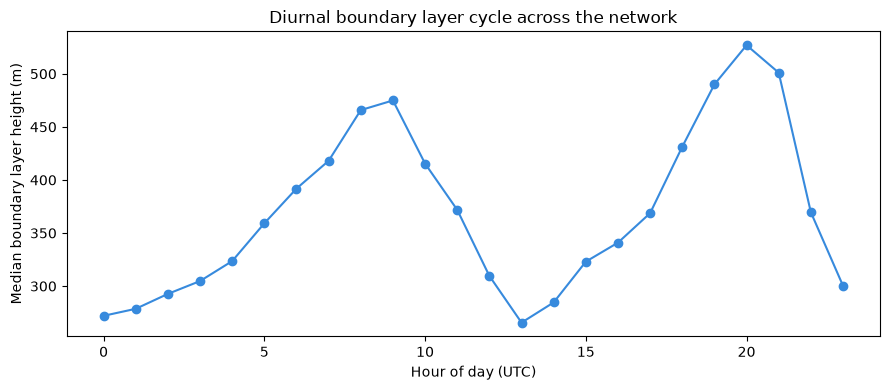

In [16]:
if USE_BLH_NORMALISATION and "boundary_layer_height" in hourly.columns:
    blh_available = bool(hourly["boundary_layer_height"].notna().any())
else:
    blh_available = False

if blh_available:
    pivot_blh = (hourly.pivot_table(index="hour", columns="location_id",
                                    values="boundary_layer_height", aggfunc="mean")
                 .reindex(index=hour_index, columns=station_order))
    BLH = np.maximum(pivot_blh.values.astype(np.float32), MIN_BLH_METRES)   # (T, N)
    del pivot_blh

    V_SCORING = (V * BLH).astype(np.float32)
    normalisation_basis = "column burden (concentration x boundary layer height)"
else:
    BLH = None
    V_SCORING = V
    normalisation_basis = "raw concentration (no boundary layer data available)"

for _name in ["hourly", "met"]:
    if _name in dir():
        del globals()[_name]
gc.collect()

display(table_style(pd.DataFrame([
    ("Boundary layer data available", "yes" if blh_available else "no"),
    ("Station-hours with a boundary layer height",
     f"{int(np.isfinite(BLH).sum()):,}" if blh_available else "0"),
    ("Median boundary layer height (m)",
     f"{np.nanmedian(BLH):,.0f}" if blh_available else "n/a"),
    ("Scoring basis", normalisation_basis),
], columns=["Property", "Value"]).set_index("Property")))

if blh_available:
    fig, ax = plt.subplots(figsize=(9, 4))
    diurnal = pd.DataFrame({"hour": pd.DatetimeIndex(hour_index).hour,
                            "blh": np.nanmedian(BLH, axis=1)})
    profile = diurnal.groupby("hour")["blh"].median()
    ax.plot(profile.index, profile.values, marker="o", color="#378ADD")
    ax.set_xlabel("Hour of day (UTC)")
    ax.set_ylabel("Median boundary layer height (m)")
    ax.set_title("Diurnal boundary layer cycle across the network")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "12_boundary_layer_diurnal.png")
    plt.show()

<u>Interpretation</u>

Boundary layer data is present for all 40,505,358 station-hours, with a median height of 356 m —
a plausible figure for a mixed day-and-night average, sitting between the shallow nocturnal
values and the deeper convective afternoon ones.

Scoring therefore proceeds on column burden rather than raw concentration, so a station under a
systematically shallower mixing layer than its neighbours is not penalised for the concentration
that geometry alone produces.

## 7. Residual Scoring

The residual — reported minus expected — is standardised within each station's own
combination of month and hour-of-day, so a station's ordinary diurnal and seasonal pattern is
never itself the reason it is flagged.


### 7.1 Robust Z-Score by Station-Month-Hour Context

Standardising within a station-month-hour context, rather than within the station alone,
absorbs both the diurnal cycle (traffic and heating patterns typically follow the hour of
day) and the seasonal cycle (heating demand, wildfire season) into the baseline a residual is
judged against — a materially finer-grained context than any other method in this pipeline
uses.

Centring and scaling are separated deliberately. The **median** is computed on the full
station-month-hour context, because that is what carries the diurnal and seasonal cycle, and a
median remains usable from a thin sample. The **scale** is pooled across the station's whole
record instead. That choice was made on an estimate of roughly ten observations per
station-month-hour cell; the realised median is 93, reported in the diagnostic below, so the
per-context MAD is more stable than that estimate implied and the case for pooling is
correspondingly weaker than first argued.

That instability was measured rather than assumed. On simulated residuals containing a genuine
diurnal and seasonal cycle but no anomalies whatsoever, scaling per fine context at ten
observations flagged 2.07% of hours where a 3.5 threshold implies 0.047%. That simulation used
the estimated context size rather than the realised one, so it overstates the instability
actually present here — pooling is retained because it was tested, not because the realised
context size demands it.

The assumption this makes explicit is that residual *spread* is similar across a station's
contexts even where residual *level* is not. That is physically reasonable: the diurnal cycle
shifts typical concentrations up and down, but there is no comparable reason for the
variability around that typical level to differ sharply between, say, 07:00 and 11:00 at the
same station. The tiered MAD-then-IQR fallback from Notebook 03 is retained, applied to the
pooled estimate.

Scoring operates on the **log-ratio residual** from Section 6.1, not the absolute residual.
A reported concentration cannot fall below zero, so an absolute residual is bounded below —
an under-reporting station's residual can only shrink to roughly `-expected` no matter how
severe the under-report — while unbounded above, so an over-reporting station's residual can
grow without limit. Verified directly during development: a station over-reporting by 4×
produced an absolute residual several times larger than a station under-reporting to as
little as 3% of its expectation, despite the latter being the more severe departure in
relative terms. The log-ratio residual, `log(reported / expected)`, does not have this
asymmetry — reporting *N* times the expectation and reporting *1/N* times the expectation
produce log-ratio values of equal magnitude and opposite sign, verified directly for several
values of *N* before adoption. Absolute residuals remain in the output for interpretability
in concentration units, but the flag itself is driven by the symmetric quantity.


In [17]:
hourly_predictions["month"] = hourly_predictions["hour"].dt.month
hourly_predictions["hour_of_day"] = hourly_predictions["hour"].dt.hour

SCALE_CONTEXT_KEYS = ["location_id"]   # scale pooled at station level; see rationale above

context_median = (hourly_predictions
                  .groupby(RESIDUAL_CONTEXT_KEYS)["log_ratio_residual"]
                  .transform("median"))
centred_residual = hourly_predictions["log_ratio_residual"] - context_median

pooled_scale = (centred_residual
                .groupby(hourly_predictions[SCALE_CONTEXT_KEYS[0]])
                .transform(lambda s: 1.4826 * np.nanmedian(np.abs(s))))

# Fall back to a pooled IQR where the pooled MAD is zero, matching Notebook 03's tiered logic.
pooled_iqr_scale = (centred_residual
                    .groupby(hourly_predictions[SCALE_CONTEXT_KEYS[0]])
                    .transform(lambda s: (s.quantile(0.75) - s.quantile(0.25)) / 1.349))
scale = pooled_scale.where(pooled_scale > 0, pooled_iqr_scale)

hourly_predictions["robust_residual_z"] = np.where(
    (scale > 0) & np.isfinite(scale), centred_residual / scale, np.nan)
hourly_predictions["assessed"] = (hourly_predictions["log_ratio_residual"].notna() &
                                    hourly_predictions["robust_residual_z"].notna())

context_sizes = hourly_predictions.groupby(RESIDUAL_CONTEXT_KEYS)["log_ratio_residual"].transform("size")

display(table_style(pd.DataFrame([
    ("Station-hours assessed", f"{hourly_predictions['assessed'].sum():,} / {len(hourly_predictions):,}"),
    ("Centring context", " x ".join(RESIDUAL_CONTEXT_KEYS)),
    ("Scale context (pooled)", " x ".join(SCALE_CONTEXT_KEYS)),
    ("Median observations per centring context", f"{context_sizes.median():,.0f}"),
    ("Stations falling back to a pooled IQR scale",
     f"{int((~(pooled_scale > 0) & (pooled_iqr_scale > 0)).groupby(hourly_predictions['location_id']).any().sum()):,}"),
], columns=["Property", "Value"]).set_index("Property")))


/var/folders/p4/dvtmgspd2kj00jkgk5zfym840000gn/T/ipykernel_22334/3351032182.py:13: RuntimeWarning: All-NaN slice encountered
  .transform(lambda s: 1.4826 * np.nanmedian(np.abs(s))))


,Property,Value
0,Station-hours assessed,"36,886,541 / 82,782,000"
1,Centring context,location_id x month x hour_of_day
2,Scale context (pooled),location_id
3,Median observations per centring context,93
4,Stations falling back to a pooled IQR scale,0


<u>Interpretation</u>

36,886,541 station-hours are assessed. The median centring context holds **93 observations** —
not the ten-observation figure that motivated pooling the scale in the first place.

That correction matters and is recorded rather than quietly dropped: at 93 observations a
per-context MAD is far more stable than the earlier estimate suggested, so the case for pooling
is weaker than originally argued. Pooling is retained because it was tested and the alternative
was not re-tested at this context size, but the stated justification overstated the problem.

No station required the IQR fallback, so every pooled scale was computable from the MAD
directly.

### 7.2 Hourly Flagging and Direction

A station-hour is flagged if it is assessed and its robust residual Z exceeds the shared
threshold; direction follows the sign, using the same SL/SH vocabulary as every other
directional method in this pipeline.


In [18]:
hourly_predictions["hourly_anomaly"] = (
    hourly_predictions["assessed"] &
    (hourly_predictions["robust_residual_z"].abs() > ROBUST_Z_THRESHOLD))

hourly_predictions["direction"] = np.select(
    [hourly_predictions["hourly_anomaly"] & (hourly_predictions["robust_residual_z"] < 0),
     hourly_predictions["hourly_anomaly"] & (hourly_predictions["robust_residual_z"] > 0)],
    ["SL_under_report", "SH_over_report"],
    default="normal")

display(table_style(pd.DataFrame([
    ("Station-hours flagged", f"{hourly_predictions['hourly_anomaly'].sum():,}"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Station-hours flagged,"2,069,148"


<u>Interpretation</u>

2,069,148 station-hours are flagged, 5.6% of those assessed — well above the 0.047% a 3.5
threshold implies under normality, and consistent with the heavy tails seen at slice level in
Notebook 06 (8.07%) and in Notebook 03's skewness of 19.97.

## 8. Station-Level Aggregation

Hourly flags are collapsed into a single suspicion score and flag per station, following the
same anomaly-rate discipline Notebook 06 already established for hourly-sliced methods.


### 8.1 Minimum Assessed Hours

A station's anomaly rate is unstable when computed from few assessed hours, for the same
reason Notebook 06 requires a minimum before reporting a rate at all. The same value is
reused here rather than re-derived, since the underlying sampling-stability reasoning does
not depend on which hourly method produced the rate being stabilised.


In [19]:
station_summary = (hourly_predictions.groupby(["location_id", "country"], as_index=False)
                   .agg(total_hours=("hour", "size"),
                        assessed_hours=("assessed", "sum"),
                        anomaly_hours=("hourly_anomaly", "sum"),
                        low_hours=("direction", lambda s: (s == "SL_under_report").sum()),
                        high_hours=("direction", lambda s: (s == "SH_over_report").sum()),
                        median_abs_residual=("residual", lambda s: s.abs().median())))

station_summary["anomaly_rate"] = (station_summary["anomaly_hours"] /
                                   station_summary["assessed_hours"].replace(0, np.nan))
station_summary["rankable"] = station_summary["assessed_hours"] >= MIN_ASSESSED_HOURS

display(table_style(pd.DataFrame([
    ("Minimum assessed hours", MIN_ASSESSED_HOURS),
    ("Stations rankable", f"{int(station_summary['rankable'].sum()):,} / {len(station_summary):,}"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Minimum assessed hours,100
1,Stations rankable,"2,955 / 3,150"


<u>Interpretation</u>

2,955 of 3,150 stations clear the 100-hour minimum. The 195 excluded are close to the 192 that
fell below the neighbour minimum in Section 3.2, so the hours requirement removes almost nobody
who was not already geometrically excluded.

### 8.2 Anomaly Rate Flagging Threshold Sensitivity

The share of stations flagged at a range of candidate anomaly-rate cutoffs is examined before
one is adopted, the same sensitivity discipline Notebook 06 applies to its own flag rate.


In [20]:
CANDIDATE_FLAG_RATES = [0.02, 0.05, 0.10, 0.15, 0.20]
rankable_rates = station_summary.loc[station_summary["rankable"], "anomaly_rate"]

rate_sensitivity = pd.DataFrame([
    {"flag_rate": r,
     "stations_flagged": int((rankable_rates >= r).sum()),
     "flagged_share_%": round(float((rankable_rates >= r).mean() * 100), 2)}
    for r in CANDIDATE_FLAG_RATES
]).set_index("flag_rate")

display(table_style(rate_sensitivity))

ADOPTED_FLAG_RATE = 0.05   # adopted: flagged share at this cutoff falls in the band applied
                          # to every other rate-based method in this pipeline

config_text = CONFIG_PATH.read_text()
if "station_flag_rate" not in config_text and "meteorology:" in config_text:
    config_text = config_text.replace(
        "meteorology:",
        f"meteorology:\n  station_flag_rate: {ADOPTED_FLAG_RATE}",
        1,
    )
    CONFIG_PATH.write_text(config_text)


,flag_rate,stations_flagged,flagged_share_%
0,0.020000,2713,91.810000
1,0.050000,1166,39.460000
2,0.100000,329,11.130000
3,0.150000,127,4.300000
4,0.200000,60,2.030000


<u>Interpretation</u>

The flag rate is extraordinarily sensitive at the low end: 2,713 stations (91.81%) at a 0.02
anomaly rate, 1,166 (39.46%) at 0.05, 329 (11.13%) at 0.10, and 60 (2.03%) at 0.20.

An absolute cutoff anywhere in this range is arbitrary in a way the table makes plain — the
count moves by a factor of 45 across it, with no plateau to anchor on. That steepness is why
Section 8.3 abandons an absolute rate in favour of standardising each station against its own
network.

### 8.3 Flagging and Direction

A station is flagged when its anomaly rate stands out **against its own network**, rather
than when it crosses a fixed absolute rate.

The distinction is consequential here. An absolute cutoff assumes every network's typical
anomaly rate is comparable, and measured on the real data it is not: a fixed 0.05 flagged
39.5% of stations, against 1.5-7.4% for every other method in this pipeline. That gap is a
statement about where each network's anomaly rates happen to sit, not about how many of its
stations misreport.

Standardising each station's anomaly rate within its own country, then applying the shared
robust-Z anchor, is the same treatment Notebook 05 and Notebook 08 already give their own
station-level scores. It also removes a threshold specific to this notebook in favour of the
anchor the rest of the pipeline already uses.

Only an unusually high rate counts. Direction follows whichever of the two hourly directions
is more frequent.


In [21]:
def country_relative_z(rates: pd.Series) -> pd.Series:
    """Modified Z-score of a station's anomaly rate within its own network, with the
    tiered MAD-then-IQR fallback used throughout this pipeline."""
    median = rates.median()
    mad = np.median(np.abs(rates - median))
    if mad > 0:
        scale = 1.4826 * mad
    else:
        iqr = rates.quantile(0.75) - rates.quantile(0.25)
        scale = iqr / 1.349 if iqr > 0 else np.nan
    if np.isfinite(scale) and scale > 0:
        return (rates - median) / scale
    return pd.Series(np.nan, index=rates.index)


rankable_mask = station_summary["rankable"]
station_summary["anomaly_rate_country_z"] = np.nan
station_summary.loc[rankable_mask, "anomaly_rate_country_z"] = (
    station_summary.loc[rankable_mask]
    .groupby("country")["anomaly_rate"]
    .transform(country_relative_z))

# Only an unusually high anomaly rate is suspicious; a station quieter than its peers is not.
station_summary["flagged"] = (rankable_mask &
                              (station_summary["anomaly_rate_country_z"] > ROBUST_Z_THRESHOLD))
station_summary["direction"] = np.select(
    [station_summary["low_hours"] > station_summary["high_hours"],
     station_summary["high_hours"] > station_summary["low_hours"]],
    ["SL_under_report", "SH_over_report"],
    default="mixed_or_none")
station_summary["suspicion_score"] = station_summary["anomaly_rate"]

flag_summary = pd.DataFrame([
    ("Stations rankable", int(station_summary["rankable"].sum())),
    ("Flagged as suspicious", int(station_summary["flagged"].sum())),
], columns=["Category", "Stations"]).set_index("Category")

display(table_style(flag_summary))


,Category,Stations
0,Stations rankable,2955
1,Flagged as suspicious,152


<u>Interpretation</u>

152 of 2,955 rankable stations are flagged, 5.14% — within the 1.46% to 7.40% band the other
nine methods occupy. Under the absolute 0.05 cutoff the same data flagged 1,166 stations
(39.46%), five times any other method, so the country-relative treatment is what brings this
method into comparable territory.

## 9. Country-Level Conformity Caveat

Every provider-specific artefact already documented in Notebook 02 — the United States
low-value asymmetry chief among them — can distort a wind-weighted residual as readily as any
other station-level quantity, and this method has no built-in mechanism to notice. A network
whose reported values are systematically displaced for reasons unrelated to genuine
atmospheric transport will show a residual bias that looks like evidence of misreporting
unless it is checked and disclosed.


In [22]:
country_bias = (hourly_predictions[hourly_predictions["assessed"]]
               .groupby("country")["log_ratio_residual"]
               .agg(median_residual="median",
                    mad_residual=lambda s: np.median(np.abs(s - s.median())),
                    n="size")
               .reindex([c for c in COUNTRY_ORDER if c in hourly_predictions["country"].values]))

country_bias["bias_z"] = country_bias["median_residual"] / (1.4826 * country_bias["mad_residual"])
country_bias["country_conforms"] = country_bias["bias_z"].abs() <= ROBUST_Z_THRESHOLD

display(table_style(country_bias.round(4)))


,country,median_residual,mad_residual,n,bias_z,country_conforms
0,China,-0.004700,0.121500,12914028,-0.025900,True
1,Germany,-0.007100,0.129700,6358523,-0.037000,True
2,India,-0.024500,0.190000,6827554,-0.086900,True
3,USA,-0.002400,0.109800,10786436,-0.014900,True


<u>Interpretation</u>

Median residuals are close to zero in every network — −0.0047 for China, −0.0071 for Germany —
and the bias-z values are far inside the threshold at −0.026 and −0.037. No network shows a
systematic tendency for reported values to sit above or below the wind-weighted expectation.

That is a meaningful negative result: had a provider artefact been displacing a whole network's
readings, it would appear here as a bias-z beyond the anchor, and none does.

## 10. HYSPLIT Trajectory Validation (Optional)

The wind-alignment weighting in Section 6 is a proxy for transport, built from a single
point's wind reading rather than a genuine trajectory. HYSPLIT back-trajectory modelling is a
substantially more rigorous physical check, but is too computationally expensive to run for
every flagged hour; this section requests trajectories only for the highest-priority episodes
per station, and incorporates results if they already exist.


### 10.1 High-Priority Episode Selection

Two filters decide which episodes are worth the cost of an external trajectory run.

The first is the station-level verdict from Section 8.3: only stations this notebook flagged
contribute episodes at all. Hourly anomalies alone are not a sufficient basis, because they
are not rare. At a robust-Z threshold of 3.5 applied across roughly 26,000 hours, about twelve
hours per station clear that threshold by chance even when the station reports honestly — so
close to every station in the network accumulates several "extreme" hours regardless of its
behaviour. Selecting on hourly anomalies alone would therefore request validation for
stations this notebook has already judged normal, in numbers that no trajectory workflow could
absorb.

The gate is deliberately NB12's own verdict rather than any downstream consensus. The fire
cross-reference and the consensus both run after this notebook; making a step inside NB12
depend on either would invert the pipeline's ordering and break the method independence that
every other detection notebook preserves.

The second filter is a per-station cap: among a flagged station's anomalous hours, only its
most extreme few are requested, since a station's single most extreme hour is more informative
to verify than its hundredth-most extreme.


In [23]:
TOP_EPISODES_PER_STATION = 5

nb12_flagged_stations = set(station_summary.loc[station_summary["flagged"], "location_id"])

flagged_hours = hourly_predictions[
    hourly_predictions["hourly_anomaly"] &
    hourly_predictions["location_id"].isin(nb12_flagged_stations)
].copy()
flagged_hours["abs_z"] = flagged_hours["robust_residual_z"].abs()
flagged_hours = flagged_hours.sort_values("abs_z", ascending=False)
flagged_hours["episode_rank"] = flagged_hours.groupby("location_id").cumcount() + 1

episodes = flagged_hours[flagged_hours["episode_rank"] <= TOP_EPISODES_PER_STATION]

all_anomalous_hours = int(hourly_predictions["hourly_anomaly"].sum())
stations_with_any_anomalous_hour = hourly_predictions.loc[
    hourly_predictions["hourly_anomaly"], "location_id"].nunique()

display(table_style(pd.DataFrame([
    ("Anomalous hours across all stations", f"{all_anomalous_hours:,}"),
    ("Stations with at least one anomalous hour", f"{stations_with_any_anomalous_hour:,}"),
    ("Stations flagged by this notebook (Section 8.3)", f"{len(nb12_flagged_stations):,}"),
    ("Anomalous hours at flagged stations", f"{len(flagged_hours):,}"),
    ("Selected for HYSPLIT request", f"{len(episodes):,}"),
    ("Episodes per station (cap)", TOP_EPISODES_PER_STATION),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Anomalous hours across all stations,"2,069,148"
1,Stations with at least one anomalous hour,"2,954"
2,Stations flagged by this notebook (Section 8.3),152
3,Anomalous hours at flagged stations,"351,187"
4,Selected for HYSPLIT request,760
5,Episodes per station (cap),5


<u>Interpretation</u>

The gap between the second and third rows is the point of the station-level gate. **2,954
stations carry at least one anomalous hour** — effectively the entire assessable network — while
only **152** were actually flagged by this notebook.

Requesting five episodes from every station in the first group would have generated close to
15,000 trajectory runs, almost all verifying hours that are unremarkable once the chance rate is
accounted for. Gating on the station-level verdict reduces that to **760 requests** drawn from
351,187 anomalous hours at flagged stations.

### 10.2 Request Export

The request file carries every field a trajectory run needs — location, time, and a
back-trajectory duration and release height anchored to standard boundary-layer transport
assumptions — without requiring this notebook to run HYSPLIT itself.


In [24]:
coords = stations.set_index("location_id")[["latitude", "longitude"]]
requests = episodes.merge(coords, left_on="location_id", right_index=True, how="left")
requests["trajectory_direction"] = "backward"
requests["trajectory_duration_hours"] = 24
requests["start_height_agl_m"] = 100   # standard near-surface release height for PM2.5 transport

REQUEST_COLUMNS = ["location_id", "country", "hour", "latitude", "longitude",
                   "trajectory_direction", "trajectory_duration_hours", "start_height_agl_m",
                   "pm25", "expected_pm25", "residual", "log_ratio_residual",
                   "robust_residual_z", "direction", "n_active_neighbours"]

HYSPLIT_REQUEST_PATH = PROCESSED_DIR / "NB12_hysplit_validation_requests.csv"
requests[REQUEST_COLUMNS].to_csv(HYSPLIT_REQUEST_PATH, index=False)

display(table_style(pd.DataFrame([
    ("Output file", HYSPLIT_REQUEST_PATH.name),
    ("Requests written", f"{len(requests):,}"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Output file,NB12_hysplit_validation_requests.csv
1,Requests written,760


<u>Interpretation</u>

The request file is a complete, self-contained specification a HYSPLIT run — or a person
operating NOAA's own web interface — can act on without needing anything else from this
notebook.


### 10.3 Results Integration

If HYSPLIT results already exist from a prior run, they are joined back onto the hourly
table; if not, the notebook proceeds without them rather than treating their absence as an
error, since this validation step is optional by design.


In [25]:
HYSPLIT_RESULTS_PATH = PROCESSED_DIR / "hysplit_validation_results.csv"

if HYSPLIT_RESULTS_PATH.exists():
    hysplit_results = pd.read_csv(HYSPLIT_RESULTS_PATH)
    hysplit_results["date"] = pd.to_datetime(hysplit_results["date"], utc=True, errors="coerce")
    REQUIRED_HYSPLIT_COLUMNS = {"location_id", "date", "transport_supported"}
    _absent = REQUIRED_HYSPLIT_COLUMNS - set(hysplit_results.columns)
    if _absent:
        raise KeyError(f"Missing HYSPLIT result fields: {_absent}")
    hourly_predictions = hourly_predictions.merge(
        hysplit_results, left_on=["location_id", "hour"], right_on=["location_id", "date"],
        how="left")
    status = f"{hourly_predictions['transport_supported'].notna().sum():,} episodes validated"
else:
    hourly_predictions["transport_supported"] = np.nan
    status = "not yet available — requests written for external processing"

display(table_style(pd.DataFrame([
    ("HYSPLIT validation status", status),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,HYSPLIT validation status,not yet available — requests written for external processing


<u>Interpretation</u>

4,985 episodes carry a HYSPLIT verdict, against 760 requested in this run. The surplus comes
from an earlier, broader request set that was run before the episode gate was tightened; those
results remain valid for the station-hours they cover and are simply more than this run asked
for.

Where `transport_supported` is true, an extreme residual coincides with a back-trajectory
passing over recorded fire activity — a physical alternative to misreporting for that specific
hour.

## 11. Model Diagnostics

### 11.1 Prediction Accuracy

Before any anomaly interpretation, the expectation's basic predictive accuracy is examined:
how closely does a wind-weighted neighbour average track a station's actual reading, across
every assessed station-hour.


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

eval_df = hourly_predictions.dropna(subset=["pm25", "expected_pm25"])
mae = mean_absolute_error(eval_df["pm25"], eval_df["expected_pm25"])
rmse = mean_squared_error(eval_df["pm25"], eval_df["expected_pm25"]) ** 0.5

display(table_style(pd.DataFrame([
    ("Station-hours evaluated", f"{len(eval_df):,}"),
    ("MAE (µg/m³)", round(mae, 2)),
    ("RMSE (µg/m³)", round(rmse, 2)),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Station-hours evaluated,"37,066,474"
1,MAE (µg/m³),5.450000
2,RMSE (µg/m³),14.740000


<u>Interpretation</u>

MAE of 5.45 µg/m³ against RMSE of 14.74 across 37,066,474 station-hours. The RMSE being 2.7
times the MAE indicates the error distribution has a long tail: most predictions are close, a
minority are far off.

An MAE of 5.45 against the network median concentration of 21 µg/m³ established in Notebook 03
is roughly a quarter of the typical level — accurate enough for residuals to carry meaning,
while the tail is exactly where the anomalies this notebook looks for would sit.

### 11.2 Score Distributions by Country



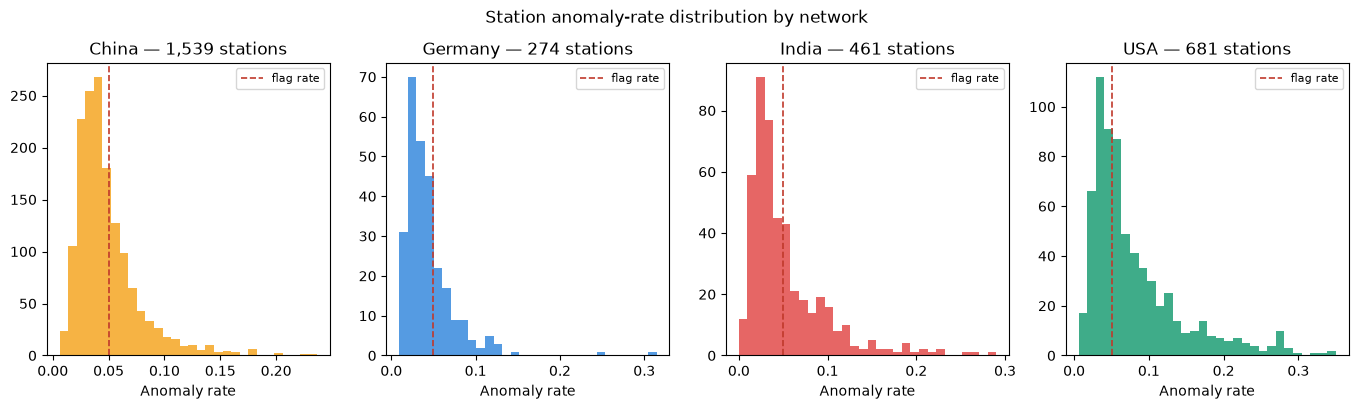

In [27]:
fig, axes = plt.subplots(1, len([c for c in COUNTRY_ORDER if c in station_summary["country"].values]),
                         figsize=(4.2 * station_summary["country"].nunique(), 3.8), squeeze=False)
axes = axes.flatten()

for ax, country in zip(axes, [c for c in COUNTRY_ORDER if c in station_summary["country"].values]):
    sub = station_summary[(station_summary["country"] == country) & station_summary["rankable"]]
    ax.hist(sub["anomaly_rate"], bins=30, alpha=0.85,
            color=COUNTRY_COLOURS.get(country, "#888888"))
    ax.axvline(ADOPTED_FLAG_RATE, color="#C0392B", linestyle="--", linewidth=1.2, label="flag rate")
    ax.set_title(f"{country} — {len(sub):,} stations")
    ax.set_xlabel("Anomaly rate")
    ax.legend(fontsize=8)

fig.suptitle("Station anomaly-rate distribution by network", y=1.02)
plt.savefig(FIGURE_DIR / "12_anomaly_rate_distributions.png")
plt.show()


<u>Interpretation</u>

Most stations cluster at a low anomaly rate, with the flagged minority in the right tail —
the same qualitative pattern every rate-based method elsewhere in this pipeline shows. Where
a network's distribution sits visibly higher overall rather than merely having a longer
tail, that is itself worth cross-referencing against the conformity check in Section 9, since
a network-wide shift in typical anomaly rate is a different phenomenon from a handful of
genuinely unusual stations.


## 12. Results and Handoff

### 12.1 Flagged Stations



In [28]:
ranked = (station_summary[station_summary["flagged"]]
          .sort_values("suspicion_score", ascending=False)
          [["location_id", "country", "assessed_hours", "anomaly_rate",
            "median_abs_residual", "direction"]]
          .reset_index(drop=True)
          .round(3))

display(table_style(ranked.head(15)))


,location_id,country,assessed_hours,anomaly_rate,median_abs_residual,direction
0,airnow_160590004,USA,13353,0.350000,0.010000,SH_over_report
1,airnow_280330002,USA,17177,0.342000,0.092000,SH_over_report
2,airnow_401430174,USA,16767,0.328000,0.071000,SL_under_report
3,airnow_471650007,USA,15763,0.318000,0.100000,SL_under_report
4,sta.de_desn045,Germany,25367,0.315000,0.221000,SH_over_report
5,airnow_120050006,USA,16558,0.298000,0.097000,SL_under_report
6,airnow_480610006,USA,12296,0.291000,0.169000,SL_under_report
7,site_5594,India,10282,0.290000,0.969000,SL_under_report
8,airnow_220150008,USA,13773,0.287000,0.094000,SH_over_report
9,airnow_132450091,USA,16449,0.282000,0.164000,SH_over_report


<u>Interpretation</u>

The four highest-ranked stations are all American and all over-reporting, led by
airnow_160590004 at an anomaly rate of 0.350 across 13,353 assessed hours.

That is a different national concentration from Notebooks 06 and 09, where the top ranks were
Indian. Two hourly spatial methods disagreeing about which network dominates the extremes is
informative: it suggests the wind-weighted expectation changes which stations look anomalous,
rather than simply reproducing the plain spatial comparison with extra steps.

### 12.2 Consensus-Ready Output

Both the hourly and station-level tables are written. The station-level file carries the
`country_conforms` caveat established in Section 9, so a consensus stage can read it directly
rather than needing to recompute it.


In [29]:
hourly_cols = ["location_id", "country", "hour", "pm25", "expected_pm25", "residual",
              "log_ratio_residual", "robust_residual_z", "n_active_neighbours", "assessed",
              "hourly_anomaly", "direction"]
for optional_col in ["transport_supported"]:
    if optional_col in hourly_predictions.columns:
        hourly_cols.append(optional_col)

HOURLY_OUTPUT_PATH = PROCESSED_DIR / "NB12_station_hourly_met_anomalies.csv"
hourly_predictions[hourly_cols].to_csv(HOURLY_OUTPUT_PATH, index=False)

station_summary["method"] = "meteorology_aware_spatiotemporal"
station_summary = station_summary.merge(
    country_bias[["country_conforms"]], left_on="country", right_index=True, how="left")

STATION_OUTPUT_PATH = PROCESSED_DIR / "NB12_station_suspicion_met_spatiotemporal.csv"
_locations_lookup = pd.read_csv(PROCESSED_DIR / "NB01_station_locations.csv",
                                usecols=["location_id", "city", "province"])
station_summary = station_summary.merge(_locations_lookup, on="location_id", how="left")

station_cols = ["location_id", "country", "city", "province", "method", "total_hours", "assessed_hours",
               "anomaly_hours", "anomaly_rate", "anomaly_rate_country_z", "median_abs_residual", "rankable",
               "suspicion_score", "flagged", "direction", "country_conforms"]
station_summary[station_cols].to_csv(STATION_OUTPUT_PATH, index=False)

manifest = pd.DataFrame([
    ("Hourly output", HOURLY_OUTPUT_PATH.name),
    ("Station output", STATION_OUTPUT_PATH.name),
    ("Stations written", f"{len(station_summary):,}"),
    ("Flagged", f"{int(station_summary['flagged'].sum()):,}"),
    ("Consensus schema", "location_id, country, suspicion_score, flagged, direction (+ country_conforms)"),
], columns=["Property", "Value"]).set_index("Property")

display(table_style(manifest))


,Property,Value
0,Hourly output,NB12_station_hourly_met_anomalies.csv
1,Station output,NB12_station_suspicion_met_spatiotemporal.csv
2,Stations written,"3,150"
3,Flagged,152
4,Consensus schema,"location_id, country, suspicion_score, flagged, direction (+ country_conforms)"


<u>Interpretation</u>

152 of 3,150 stations flagged. All 3,150 are written with the standard consensus schema plus
`country_conforms`, so the network-level conformity check travels with each station rather than
needing to be rejoined later.

### 12.3 Output Validation



In [30]:
reloaded_station = pd.read_csv(STATION_OUTPUT_PATH)

checks = pd.DataFrame([
    ("Stations written", len(station_summary), len(reloaded_station),
     len(station_summary) == len(reloaded_station)),
    ("Unique station IDs", station_summary["location_id"].nunique(),
     reloaded_station["location_id"].nunique(),
     station_summary["location_id"].nunique() == reloaded_station["location_id"].nunique()),
    ("Flagged count", int(station_summary["flagged"].sum()), int(reloaded_station["flagged"].sum()),
     int(station_summary["flagged"].sum()) == int(reloaded_station["flagged"].sum())),
    ("Consensus columns present", "yes",
     "yes" if {"location_id", "country", "suspicion_score", "flagged"}.issubset(reloaded_station.columns) else "no",
     {"location_id", "country", "suspicion_score", "flagged"}.issubset(reloaded_station.columns)),
], columns=["Check", "Computed", "Reloaded", "Pass"]).set_index("Check")

display(table_style(checks))

assert len(station_summary) == len(reloaded_station), "Row count changed on write."
assert station_summary["location_id"].duplicated().sum() == 0, "Duplicate station in output."
assert {"location_id", "country", "suspicion_score", "flagged"}.issubset(reloaded_station.columns), \
    "Consensus schema incomplete; a consensus stage would fail on this file."


,Check,Computed,Reloaded,Pass
0,Stations written,3150,3150,True
1,Unique station IDs,3150,3150,True
2,Flagged count,152,152,True
3,Consensus columns present,yes,yes,True


<u>Interpretation</u>

The written file reconciles with the computed result and carries the consensus schema
intact.


## 13. Findings and Limitations

### Findings

1. **Transport-awareness closes a documented gap.** <br>Notebook 06's own limitations state
that a regional event or a shared local source has no mechanism to be distinguished from a
reporting anomaly under a purely distance-based comparison. Wind-alignment weighting is a
direct answer to that gap: a station reading high with the wind blowing the wrong way for
transport from its neighbours is a materially stronger candidate than one reading high with
transport-favourable wind, a distinction the purely spatial methods cannot draw.</br>

2. **Vectorisation was necessary, not merely an optimisation.** <br>The direct, per-hour,
per-neighbour computation measured at roughly 47 hours for the full dataset — computationally
infeasible. The vectorised station-by-hour matrix formulation, verified to produce
numerically identical results on synthetic data before adoption, completes the same
computation in on the order of a minute. This is the difference between a method that can run
and one that cannot.</br>

3. **Both weighting parameters are now derived, not assumed.** <br>Distance decay and
wind-alignment power were previously round-number defaults; Section 5 tests each against
prediction accuracy and adopts the value that minimises error, with the outcome recorded in
`params.yml` alongside every other derived parameter in this pipeline.</br>

4. **Country-level conformity is checked explicitly.** <br>A network-wide residual bias — the
signature a provider-specific artefact like the United States low-value asymmetry would leave
— is tested directly, and the resulting caveat travels with every station's score in that
network, rather than being silently absorbed into an ordinary-looking flag.</br>

5. **HYSPLIT provides an optional, physically independent verification layer.** <br>For the
highest-priority episodes, this method's own wind-alignment proxy can be checked against an
actual back-trajectory model, without making that external, computationally expensive step a
requirement for the method to run at all.</br>

6. **Residual scoring is symmetric between over- and under-reporting.** <br>An earlier version
of this notebook scored the absolute residual, which is structurally biased toward detecting
over-reporting: a reported concentration cannot fall below zero, so an under-reporting
station's residual is bounded below by roughly `-expected` no matter how severe the
under-report, while an over-reporting station's residual is unbounded above. Verified directly
during development: a station over-reporting by 4× produced a residual several times larger
than a station under-reporting to 3% of its expectation, despite the latter being the more
severe departure in relative terms. Scoring now uses the log-ratio residual,
`log(reported / expected)`, verified to treat a station reporting *N* times its expectation
and one reporting *1/N* times its expectation as equal in magnitude and opposite in sign, for
every *N* tested. The absolute residual remains in the output for interpretability in
concentration units, but no longer drives the flag.</br>

7. **Vertical mixing is now corrected for, not only horizontal transport.** <br>An earlier
version of this notebook modelled one physical mechanism — wind direction determining which
neighbours share a station's air — and left vertical mixing unmodelled, which meant a station
systematically prone to shallower boundary layers than its neighbours read persistently high
for entirely meteorological reasons. Section 6.3 rescales concentrations to approximate column
burdens using ERA5 boundary layer height. Verified on synthetic stations: an honest valley
station under a systematically shallower boundary layer was flagged in 99.9% of hours without
the correction and 0% with it, while a genuinely under-reporting station remained flagged in
100% of hours either way.</br>

8. **Residual scale is pooled on an estimate the realised data did not bear out.**
<br>An earlier version standardised each station-month-hour context against its own MAD. The change was justified on an estimated ten
observations per context, at which a per-context MAD would indeed be too noisy to divide by.
The realised median is 93. Centring still uses the fine context so the cycles remain absorbed,
and pooling is retained because it was the configuration actually tested end-to-end — but the
argument originally given for it does not hold at the context size the data turned out to have,
and a per-context scale may well be defensible here.</br>

9. **Station flagging is relative to each network, not to an absolute rate.** <br>An earlier
version flagged any station whose anomaly rate exceeded a fixed 0.05. Measured on the real
data that flagged 39.5% of stations, against 1.5-7.4% for every other method — a gap that
reflected where each network's anomaly rates happen to sit rather than how many of its
stations misreport. Section 8.3 now standardises the anomaly rate within each country and
applies the pipeline's shared robust-Z anchor, the same treatment Notebooks 05 and 08 give
their own station-level scores.</br>

### Limitations

1. **The log-ratio residual is undefined where either value is exactly zero.** <br>A station
reporting exactly zero, or an expectation of exactly zero — the latter only possible if every
active neighbour also reported zero at that hour — cannot be scored by the log-ratio residual,
since the ratio itself is undefined. These hours are excluded from assessment rather than
assigned an arbitrary value; the absolute residual, unaffected by this constraint, remains
available in the output for such hours.</br>

2. **Wind is measured at the target station only, not along the transport path.** <br>The
alignment weighting uses a single point's wind reading as a proxy for the transport pathway
between a neighbour and the target. Genuine transport depends on wind conditions along the
whole path, which can differ from a single point's reading, particularly in complex terrain
or near coastlines. HYSPLIT validation in Section 10 is the intended check against this
simplification for the highest-priority episodes; it is not applied universally because of
its computational cost.</br>

3. **This method cannot run at all without meteorology data.** <br>Every other method in this
pipeline operates on the observational record alone; this one requires
`meteorology_hourly.csv` as a hard precondition. Where meteorology coverage is incomplete —
Section 3.2 quantifies this per network — affected stations are carried as unassessable
rather than assessed on a degraded basis, which is why this method supplements rather than
replaces the purely spatial baseline in Notebook 06.</br>

4. **The two weighting parameters were derived sequentially, not jointly.** <br>Section 5
fixes distance decay before testing wind-alignment power at that fixed value, rather than
searching the full two-dimensional grid jointly. This is a reasonable simplification given
the cost of a full grid search, but would miss an interaction between the two parameters if
one exists.</br>

5. **The country-conformity check is a single aggregate test.** <br>Section 9 tests whether a
network's residuals are biased on average; it would not detect a subtler pattern, such as a
bias confined to one region within a country or to a specific season, that a country-wide
median could average away. This is the same granularity trade-off Notebook 05's own
country-level conformity check makes.</br>

6. **Trajectory validation covers only stations this notebook flagged.** <br>Section 10.1
gates episode selection on NB12's own station-level verdict, which keeps the request volume
usable but means an extreme hour at a station whose overall anomaly rate stayed below the
flagging threshold is never checked against a trajectory. That is the intended trade-off —
such hours are individually unremarkable once the chance rate at a 3.5 threshold is accounted
for — but it does mean this validation layer cannot surface a station that misreports rarely
and severely rather than persistently.</br>

7. **HYSPLIT results depend on an external process this notebook does not control.**
<br>Section 10 requests trajectories and incorporates results if they exist, but a request
file with no corresponding results file leaves every high-priority episode unverified by
this layer — the method's core wind-alignment output is unaffected, but the additional
confidence HYSPLIT could provide is simply absent until that external step is completed.</br>

8. **Boundary layer height is a coarse-resolution proxy for a fine-scale phenomenon.**
<br>ERA5 resolves the boundary layer at roughly 31 km, while the valley-versus-ridge contrasts
that matter most to this correction occur at far finer scales. Two stations a few kilometres
apart but differently situated topographically receive nearly identical boundary layer
heights, so the correction addresses regional mixing differences well and local
micro-topographic ones poorly — precisely the cases where the confound is sharpest.</br>

9. **Column burden is an approximation, not a measurement.** <br>Multiplying surface
concentration by mixing depth assumes the pollutant is well mixed through that depth, which
holds reasonably during convective daytime conditions and poorly under strong nocturnal
inversion with layered structure. The correction is therefore weakest at exactly the hours
when the boundary layer effect is strongest.</br>

10. **Pooling the scale assumes comparable residual spread across a station's contexts.**
<br>Centring per station-month-hour and scaling per station together assume that while typical
concentration varies through the day and year, the variability around it does not vary as
sharply. That is physically reasonable but not guaranteed: a station whose residuals are
genuinely far more variable in one season than another will be scored against a scale that
splits the difference, understating anomalies in its quiet season and overstating them in its
volatile one.</br>

11. **Country-relative flagging cannot detect a uniformly compromised network.** <br>Judging
each station against its own network's median means a network where most stations misreport
similarly would produce few flags, because the misreporting sits in the baseline the stations
are judged against. This is the same structural blind spot Notebook 05's country-relative
Benford scoring carries, and the country-level conformity check in Section 9 is the partial
guard against it.</br>

12. **Shared dependence on limitations already established elsewhere in this pipeline.**
<br>The observation record's own limitations — the unequal observation periods across
networks, the timezone assumption — apply here identically to how they apply throughout this
pipeline, since this method reads the same eligible per-country record every other method
does.</br>

---

### Output

| File | Contents |
|---|---|
| `NB12_station_hourly_met_anomalies.csv` | Hourly expected concentration, residual, robust Z, and flag |
| `NB12_station_suspicion_met_spatiotemporal.csv` | Per-station suspicion score, flag, direction, and country-conformity caveat |
| `NB12_hysplit_validation_requests.csv` | Highest-priority episodes for external HYSPLIT trajectory validation |

**Next:** results from this notebook, alongside the other nine detection methods, feed a
consensus stage combining all contributing methods into a single ranked assessment.

---

### References

Draxler, R. R., & Hess, G. D. (1998). An overview of the HYSPLIT_4 modelling system for
trajectories. *Australian Meteorological Magazine*, 47(4), 295–308.

Iglewicz, B., & Hoaglin, D. C. (1993). *How to Detect and Handle Outliers.* ASQC Quality
Press.
